In [1]:
from llm_call import llm
from langchain.tools import tool
from langchain_core.messages import HumanMessage
from langchain_mcp_adapters.client import MultiServerMCPClient


In [2]:
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder, PromptTemplate, SystemMessagePromptTemplate

def create_tool_agent(llm, tools: list, system_prompt: str):
    """Helper function to create agents with custom tools and system prompt
    Args:
        llm: LLM for the agent
        tools (list): list of tools the agent will use
        system_prompt (str): text describing specific agent purpose

    Returns:
        executor (AgentExecutor): Runnable for the agent created.
    """
    
    # Each worker node will be given a name and some tools.
    
    system_prompt_template = PromptTemplate(

                template= system_prompt + """
                ONLY respond to the part of query relevant to your purpose.
                IGNORE tasks you can't complete. 
                Use the following agent history to answer your query if available: \n {agent_history} \n
                If you do not have a tool to answer the question, say so.
                If you require any other information from the user, ask them for it.
                If you are not sure about the answer, say so.
                """,
                input_variables=["agent_history"],
            )

    #define system message
    system_message_prompt = SystemMessagePromptTemplate(prompt=system_prompt_template)

    prompt = ChatPromptTemplate.from_messages(
        [system_message_prompt,
            MessagesPlaceholder(variable_name="messages"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ]
    )
    agent = create_tool_calling_agent(llm, tools, prompt)
    executor = AgentExecutor(agent=agent, tools=tools, return_intermediate_steps= True, verbose = False)
    return executor

In [3]:
client = MultiServerMCPClient(
    {
        "test": {
            "url": "http://localhost:8000/mcp",
            "transport": "streamable_http",
        }
    }
)

In [4]:
tools = await client.get_tools(server_name="test")
print(tools)

llm.bind_tools(tools)

# await client.get_prompt(server_name="test", prompt_name="default")
# ["users://{user_id}/profile", "greet://{name}"]
# await client.get_resources(server_name="test", uris=["users://101/profile", "greet://atharva"])

[StructuredTool(name='example_tool', description='This is an example tool that echoes the input text.', args_schema={'properties': {'input_text': {'title': 'Input Text', 'type': 'string'}}, 'required': ['input_text'], 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x7efeec44bce0>), StructuredTool(name='addition_tool', description='This tool adds two integers and returns the result.', args_schema={'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x7efeec44bba0>), StructuredTool(name='body_check_tool', description='This tool checks the body of the request and returns a message.', args_schema={'$defs': {'CustomBody': {'description': 'Custom body model for the body_check_tool.', 'properties': {'name

RunnableBinding(bound=ChatGoogleGenerativeAI(model='models/gemini-2.5-flash', google_api_key=SecretStr('**********'), temperature=0.0, client=<google.ai.generativelanguage_v1beta.services.generative_service.client.GenerativeServiceClient object at 0x7efef636f680>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'example_tool', 'description': 'This is an example tool that echoes the input text.', 'parameters': {'properties': {'input_text': {'type': 'string'}}, 'required': ['input_text'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'addition_tool', 'description': 'This tool adds two integers and returns the result.', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'body_check_tool', 'description': 'This tool checks the body of the request and returns a message.', 'parameters': {'properties': {'body'

In [5]:
# @tool
# def capitalize(input: str) -> str:
#     """Tool 1: Capitalizes the input string."""
#     print("I am capitalize tool")
#     return input.upper() + str("  Successfully capitalized the string.")

super_agent = create_tool_agent(
    llm=llm,
    tools=tools,
    system_prompt="You are a super agent. You have multiple tools via. mcp server, use them when required to answer the queries."
)

In [6]:
# @tool
# def addition(a: int, b: int) -> str:
#     """Tool 2: Adds two numbers in the input string."""
#     print("I am addition tool")
#     return str(a + b) + str(" Successfully added two numbers.")

# math_agent = create_tool_agent(
#     llm=llm,
#     tools=[addition],
#     system_prompt="You are a math agent. You can add two numbers in the input string. "
# )

In [7]:

# system_prompt_template = PromptTemplate(

#                 template= """ You are a planner agent. You will receive a query from user. You're task is to create a plan to solve the query using the available agents.
#                 You will use the following agents:
#                 1. Super Agent: {super_agent_name} - This agent can perform mathematical tasks and other tools.
#                 2. Communicate: Use this agent to finalize the response to the user.
#                 Create the plan and give it to the supervisor agent.
#                         \n{agent_history}\n""",
#                 input_variables=["agent_history"],  )

# system_message_prompt = SystemMessagePromptTemplate(prompt=system_prompt_template)

# prompt = ChatPromptTemplate.from_messages(
#     [
#         system_message_prompt,
#         MessagesPlaceholder(variable_name="messages"),
#     ])

# planner_agent = (prompt| llm) 

In [8]:
# planner_agent.invoke({"messages": [HumanMessage(content="Add 2 and 3 also capitalize the word `banana`")], "agent_history": [""]})

In [9]:
from langchain_core.messages import AIMessage
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_core.output_parsers import JsonOutputParser

#define output structure
class CommsOutput(BaseModel):
    messages: AIMessage = Field(description = 'Friendly and helpful agent response to the human query')

    class Config:
        arbitrary_types_allowed = True

#create the parser for the chain based on specified output
comms_parser = JsonOutputParser(pydantic_object=CommsOutput)

system_prompt_template = PromptTemplate(

                template= """ You are a talkative and helpful assistant that summarises agent history 
                            in response to the original user query below. 
                            SUMMARISE ALL THE OUTPUTS AND TOOLS USED in agent_history.
                            The agent history is as follows: 
                        \n{agent_history}\n
                        You will provide a friendly and helpful response to the user query. do not include any tools or agent history in your response. Just a friendly response.""",
                input_variables=["agent_history"],  )

system_message_prompt = SystemMessagePromptTemplate(prompt=system_prompt_template)

prompt = ChatPromptTemplate.from_messages(
    [
        system_message_prompt,
        MessagesPlaceholder(variable_name="messages"),
    ])

comms_agent = (prompt| llm) 

/home/atharva_shirke/MCP_server/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3699: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)


In [10]:
# from langchain_core.messages import HumanMessage
# text_output = text_agent.invoke({"messages": [HumanMessage(content="car")], "agent_history": []})
# comms_outputs = comms_agent.invoke({"messages": [HumanMessage(content="car")], "agent_history": [text_output]})
# # print(text_output)
# print(comms_outputs)

In [11]:
from enum import Enum
members = ["Super Agent", "Communicate"]

#create options map for the supervisor output parser.
member_options = {member:member for member in members}

#create Enum object
MemberEnum = Enum('MemberEnum', member_options)

from pydantic import BaseModel

#force Supervisor to pick from options defined above
# return a dictionary specifying the next agent to call 
#under key next.
class SupervisorOutput(BaseModel):
    #defaults to communication agent
    next: MemberEnum = MemberEnum.Communicate 

In [12]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import JsonOutputParser
from langchain.output_parsers import OutputFixingParser



system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    " crew of workers:  {members}. "
    "Go to the Super Agent for your tasks."
    "You will receive a query from the user and the agent history. "
    "You will use MCP server tools given to you to perform the operation."
    "After completing the task you will route the response to the communication agent."
    "Then finish the task."
    "Use the mcp server and tools and do mention when used."
            "Select one of: {options} "
            "\n{format_instructions}\n"
)
# Our team supervisor is an LLM node. It just picks the next agent to process
# and decides when the work is completed

# Using openai function calling can make output parsing easier for us
supervisor_parser = JsonOutputParser(pydantic_object=SupervisorOutput)

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages"),
        MessagesPlaceholder(variable_name="agent_history")
       
    ]
).partial(
    options=str(members),
    members=", ".join(members),
    format_instructions=supervisor_parser.get_format_instructions())

new_parser = OutputFixingParser.from_llm(parser=supervisor_parser, llm=llm)



supervisor_chain = (
    prompt | llm |new_parser
)

In [13]:
from langchain_core.messages import AIMessage

# For agents in the crew 
async def crew_nodes(state, crew_member, name):
    # print(name)
    input = {'messages': [state['messages'][-1]], 'agent_history' : state['agent_history']}
    result = await crew_member.ainvoke(input)
    # print(result)

    return {"agent_history": [AIMessage(content= result["output"], additional_kwargs= {'intermediate_steps' : result['intermediate_steps']}, name=name)]}

def comms_node(state):
    input = {'messages': [state['messages'][-1]], 'agent_history' : state['agent_history']}
    result = comms_agent.invoke(input)
    return {"messages": [result]}

# def planner_node(state):
#     input = {'messages': [state['messages'][-1]], 'agent_history' : state['agent_history']}
#     result = planner_agent.invoke(input)
#     return {"messages": [result]}


In [14]:
import operator
from typing import Annotated, Sequence, TypedDict
import functools
from langchain_core.messages import BaseMessage

from langgraph.graph import StateGraph, END


# The agent state is the input to each node in the graph
class AgentState(TypedDict):
    # The annotation tells the graph that new messages will always
    # be added to the current states
    messages: Annotated[Sequence[BaseMessage], operator.add]
    # The 'next' field indicates where to route to next
    next: str 
    
    agent_history: Annotated[Sequence[BaseMessage], operator.add]


super_node = functools.partial(crew_nodes, crew_member=super_agent, name="SuperAgent")

# text_node = functools.partial(crew_nodes, crew_member=text_agent, name="TextAgent")

# api_node = functools.partial(crew_nodes, crew_member=api_agent, name="API Agent")



workflow = StateGraph(AgentState)

# workflow.add_node("Text Agent", text_node)
workflow.add_node("Super Agent", super_node)
# workflow.add_node("API Agent", api_nod/e)

workflow.add_node("Communicate", comms_node)
# workflow.add_node("Planner Agent", planner_node)

workflow.add_node("Supervisor", supervisor_chain)

In [15]:

# workflow.add_edge('Supervisor', "Text Agent") # add one edge for each of the agents
# workflow.add_edge('Supervisor', "Math Agent") # add one edge for each of the agents
# workflow.add_edge('API Agent', "Supervisor") # add one edge for each of the agents
workflow.add_edge("Super Agent", 'Supervisor') # add one edge for the planner agent to communicate
# workflow.add_edge('Supervisor', 'Communicate') # add one edge for the supervisor to communicate
# workflow.add_edge('Text Agent', 'Supervisor') # add one edge for the text agent to communicate
# workflow.add_edge('Math Agent', 'Supervisor') # add one edge for the math agent
# workflow.add_conditional_edges("Supervisor", lambda x: x["next"], member_options)
workflow.add_conditional_edges(
    "Supervisor",
    lambda x: x["next"],  # next must match a node name!
    ["Super Agent", "Communicate"]  # possible destinations
)
# workflow.add_edge('Text Agent', 'Communicate') # add one edge for the text agent to communicate
# workflow.add_edge('Math Agent', 'Communicate') # add one edge for the math agent
workflow.add_edge('Communicate', END) # add one edge for each of the agents

# The supervisor populates the "next" field in the graph state
# which routes to a node or finishes


# Finally, add entrypoint
workflow.set_entry_point("Supervisor")

In [16]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

graph = workflow.compile(
    # interrupt_before=["Communicate"],
    checkpointer=checkpointer
)

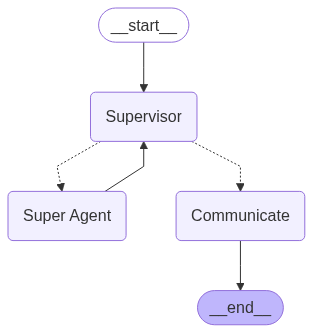

In [17]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [18]:
print(graph.input_schema)

<class 'langgraph.graph.state.LangGraphInput'>


In [19]:
query = "Add 2 and 3."
history = [
            HumanMessage(content=""),
            AIMessage(content="")
        ]

In [20]:
# config = {"configurable": {"thread_id": "test_2"}}
# inputs = {"messages": [("user", f"{query}")], "agent_history": [""], "next": "Planner Agent"}

# from pprint import pp
# # call our graph with streaming to see the steps
# for state in graph.stream(inputs, config= config, stream_mode="values"):
#     last_message = state["messages"][-1]
#     pp(last_message)

In [25]:
config = {"configurable": {"thread_id": "newassds"}}
from pprint import pp
async for s in graph.astream(
    {
        "messages": [
            HumanMessage(content="How many agents you have to use?"),
        ],
        "next": "Supervisor",
        "agent_history": [
            HumanMessage(content=""),
        ]
    }, config=config
):
    
    if "__end__" not in s:
        pp(s)
        print("----")

/home/atharva_shirke/MCP_server/.venv/lib/python3.12/site-packages/langchain_google_genai/chat_models.py:1663: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


{'Supervisor': {'next': 'Communicate'}}
----
{'Communicate': {'messages': [AIMessage(content="It's a great question! The number of agents I might use really depends on the task at hand. For simpler requests, one agent might be all that's needed to get the job done efficiently. However, for more complex or multi-faceted problems, I can orchestrate several specialized agents to work together, each handling a different part of the problem to ensure we get the best possible outcome. It's all about finding the right approach for your specific needs!", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--d088de00-c895-4da1-b4e7-053d808d8b5f-0', usage_metadata={'input_tokens': 154, 'output_tokens': 95, 'total_tokens': 1953, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 1704}})]}}
----


In [22]:
# config = {"configurable": {"thread_id": "test"}}
# from pprint import pp
# for s in graph.stream(
#     {
#         "messages": [
#             HumanMessage(content=query),
#         ],
#         "next": "Planner Agent",
#         "agent_history": history
#     }, config=config
# ):
    
#     if "__end__" not in s:
#         pp(s)
#         history = [
#             HumanMessage(content=query),
#             AIMessage(content=s["messages"][0].content)  # Assuming the first message is the AI response
#         ]
#         print("----")